# Automatidata_Exploratory Data Analysis
Go Beyond the Numbers: Translate Data into Insights

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C2 and perform further EDA on this data with the aim of learning more about the variables. 
  
**The goal** is to clean data set and create a visualization.

### This activity has 4 parts:
**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Building visualizations

**Part 4:** Evaluate and share results

## PACE: Plan
Our plan is to identify any outliers:


*   What methods are best for identifying outliers?
  * Use numpy functions to investigate the `mean()` and `median()` of the data and understand range of data values
  * Use a boxplot to visualize the distribution of the data
  * Use histograms to visualize the distribution of the data
*   How do you make the decision to keep or exclude outliers from any future models?
  * There are three main options for dealing with outliers: keeping them as they are, deleting them, or reassigning them. Whether you keep outliers as they are, delete them, or reassign values is a decision that you make taking into account the nature of the outlying data and the assumptions of the model you are building. To help you make the decision, you can start with these general guidelines:

      * Delete them: If you are sure the outliers are mistakes, typos, or errors and the dataset will be used for modeling or machine learning, then you are more likely to decide to delete outliers. Of the three choices, you’ll use this one the least.
      * Reassign them: If the dataset is small and/or the data will be used for modeling or machine learning, you are more likely to choose a path of deriving new values to replace the outlier values.
      * Leave them: For a dataset that you plan to do EDA/analysis on and nothing else, or for a dataset you are preparing for a model that is resistant to outliers, it is most likely that you are going to leave them in.

## Task 1. Imports, links, and loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import seaborn as sns 

In [2]:
df=pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

## PACE: Analyze

Start by discovering, using head and size. 

In [3]:
df.head(10)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36
6,37660487,2,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,1,12.83,1,N,79,241,1,47.5,1.0,0.5,9.86,0.0,0.3,59.16
7,69059411,2,08/15/2017 5:41:06 PM,08/15/2017 6:03:05 PM,1,2.98,1,N,237,114,1,16.0,1.0,0.5,1.78,0.0,0.3,19.58
8,8433159,2,02/04/2017 4:17:07 PM,02/04/2017 4:29:14 PM,1,1.20,1,N,234,249,2,9.0,0.0,0.5,0.00,0.0,0.3,9.80
9,95294817,1,11/10/2017 3:20:29 PM,11/10/2017 3:40:55 PM,1,1.60,1,N,239,237,1,13.0,0.0,0.5,2.75,0.0,0.3,16.55


In [4]:
df.size

408582

In [5]:
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

This dataset has 22,699 rows and 18 columns. There is no null values. 

## Task 2b. Assess whether dimensions and measures are correct

In [7]:
df.dtypes

Unnamed: 0                 int64
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

Date related columns are object type which need to be changed to datetime.

## Task 2c. Select visualization type(s)

In this section, we will select data visualization types that will help us understand and explain the data.
A bar chart, box plot and scatter plot will be most helpful in our understanding of the data.

- A box plot will be helpful to determine outliers and where the bulk of the data points reside in terms of trip_distance, duration, and total_amount

- A scatter plot will be helpful to visualize the trends and patters and outliers of critical variables, such as trip_distance and total_amount

- A bar chart will help determine average number of trips per month, weekday, weekend, etc


## PACE: Construct

## Task 3. Data visualization

## Boxplots

Here, we will perform a check for outliers on relevant columns such as trip distance and trip duration. Some of the best ways to identify the presence of outliers in data are box plots and histograms. 

In [8]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [9]:
# Convert data columns to datetime
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])

**trip_distance**

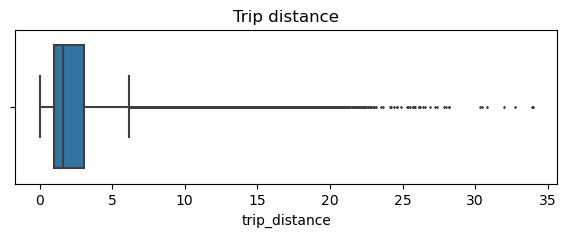

In [10]:
plt.figure(figsize=(7,2))
plt.title('Trip distance')
sns.boxplot(data=None, x=df['trip_distance'], fliersize=1)
plt.show()

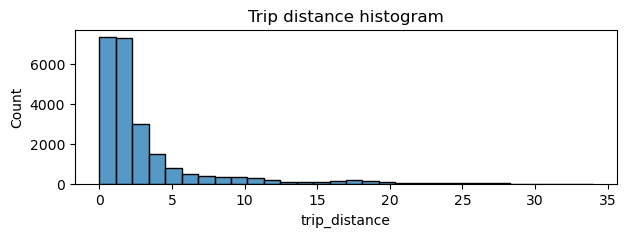

In [11]:
plt.figure(figsize=(7,2))
plt.title('Trip distance histogram')
sns.histplot(x=df['trip_distance'], bins=30)
plt.show()

The majority of trips were less than two miles long. 
By increasing the trip distance, number of trips decresaes steeply. 
The distribution of trip_distance is right skewed with most data concentrated in the left side and longer tail towards right side. 

**total_amount**

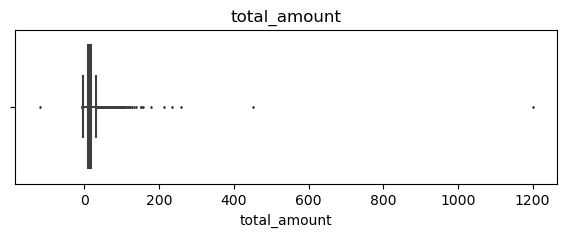

In [12]:
plt.figure(figsize=(7,2))
plt.title('total_amount')
sns.boxplot(x=df['total_amount'], fliersize=1);

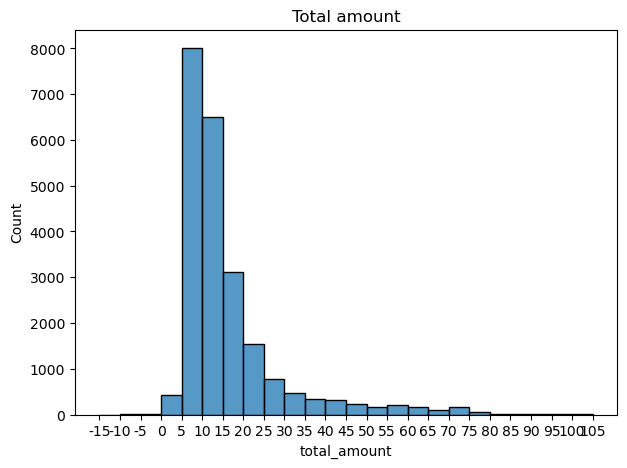

In [13]:
plt.figure(figsize=(7,5))
plt.title('Total amount')
ax = sns.histplot(x=df['total_amount'], bins=range(-15,110,5))

ax.set_xticks(range(-15,110,5))
ax.set_xticklabels(range(-15,110,5))
plt.show()

Total cost of the most of the trips all in the range of 5-20$. Since the right tail of the histogram is longer than the left tail, the majority of the data values are concentrated on the left side of the plot, with fewer values extending towards the right and we have right skew in our distribution of total_amount. 

**tip_amount**

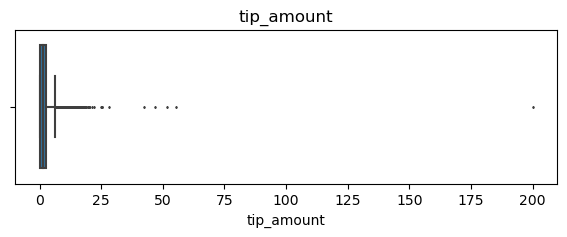

In [14]:
plt.figure(figsize=(7,2))
plt.title('tip_amount')
sns.boxplot(x=df['tip_amount'], fliersize=1);

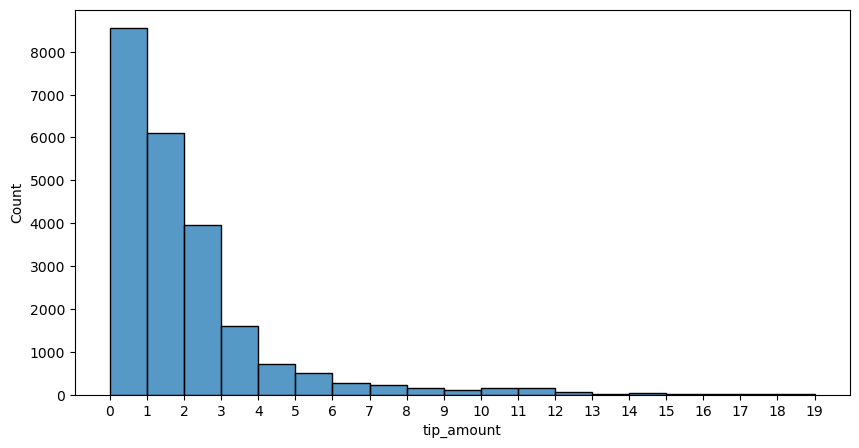

In [15]:
plt.figure(figsize=(10,5))
ax = sns.histplot(df['tip_amount'], bins=range(0,20,1))
ax.set_xticks(range(0,20,1))
ax.set_xticklabels(range(0,20,1))
plt.show()

- The histplot of tip_amount also shows a right skewed graph with most of the tip_amount ranges in the 0-3$

**tip_amount by Vendor ID**

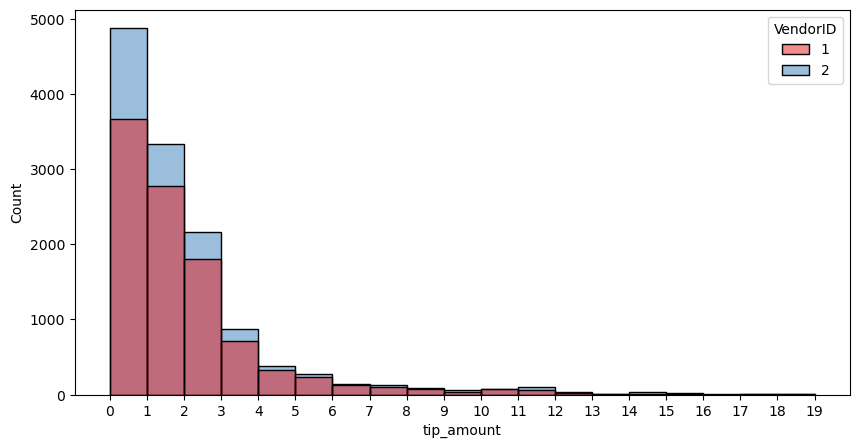

In [16]:
plt.figure(figsize=(10,5))
ax = sns.histplot(data=df, x=df['tip_amount'],hue='VendorID', bins=range(0,20,1), palette="Set1")
ax.set_xticks(range(0,20,1))
ax.set_xticklabels(range(0,20,1))
plt.show()

Similar tip_amount distribution and trend is observed in the histplot above for both VendorID 1 and VendorID 2 and no noticabl aberration between the two is obtained. 
However, VendorID 2 has slightly higher higher share of the rides which is almost the same for all the tip_amounts. Since it is not very obvious what is the trend at higher tip_amounts, we can plot zoomed in histplot for clarification.  

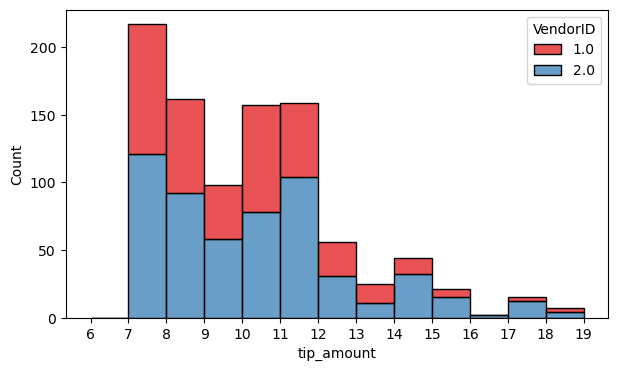

In [17]:
plt.figure(figsize=(7,4))
ax = sns.histplot(data=df[df['tip_amount']>=7], x=df['tip_amount'],hue='VendorID', bins=range(6,20,1), palette="Set1", multiple='stack')
ax.set_xticks(range(6,20,1))
ax.set_xticklabels(range(6,20,1))
plt.show()

As can be seen in the histplot above, the trend is the same even at igher tip_amount values. 

**mean of tip_amount by passenger_count**

- let's find the unique values of passenger_count column

In [18]:
df['passenger_count'].value_counts()/sum(df['passenger_count'].value_counts())

passenger_count
1    0.710031
2    0.145601
5    0.050355
3    0.041984
6    0.030530
4    0.020045
0    0.001454
Name: count, dtype: float64

- Unique number of passengers varies between 0 and 6. 
- 70% of the rides have 1 passenger.  
 Next we can find the mean of tip_amount by passenger_count. 

In [19]:
passenger_mean_tip = df[['passenger_count','tip_amount']].groupby('passenger_count').mean('tip_amount').reset_index()
passenger_mean_tip

,passenger_count,tip_amount
0,0,2.135758
1,1,1.848920
2,2,1.856378
3,3,1.716768
4,4,1.530264
5,5,1.873185
6,6,1.720260


- almost the mean of tip_amount of ~ 1.7-1.85 $ is observed for the trips with 1 to 6 passengers. 
- We have 0.1% of the rides with 0 passengers which doesn't make sense. Therefore, these would be most probably dropped from the dataset. 

In [20]:
no_zero_passenger_mean_tip = passenger_mean_tip[passenger_mean_tip['passenger_count']>0]
no_zero_passenger_mean_tip

,passenger_count,tip_amount
1,1,1.848920
2,2,1.856378
3,3,1.716768
4,4,1.530264
5,5,1.873185
6,6,1.720260


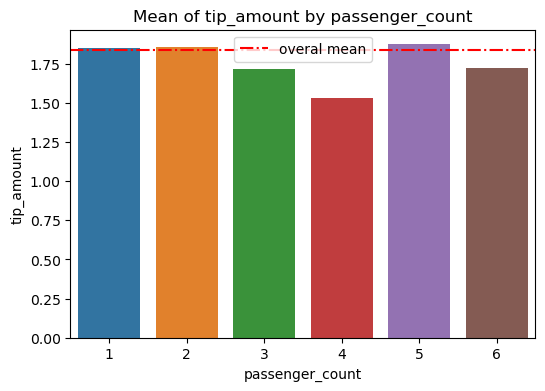

In [21]:
plt.figure(figsize=(6,4))
ax = sns.barplot(x=no_zero_passenger_mean_tip['passenger_count'], y=no_zero_passenger_mean_tip['tip_amount'])
ax.axhline(df['tip_amount'].mean(), label = 'overal mean', ls = '-.', color='red')
ax.legend()
plt.title ('Mean of tip_amount by passenger_count')
plt.show()

- Mean of tip_amount variation by nuber of passengers is small. The average of tip_amount for each category of passenger count looks the same for all counts except rides with passenger count of 4. passenger_count of 4 was the least numbers as observed in passenger count data of 2%. Hgher fluctuation is expected for the count of 4 passengers.  

** **

In [22]:
df['time_diff'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['min_diff'] = df['time_diff'].dt.total_seconds() / 60
df['min_diff'] 

0        14.066667
1        26.500000
2         7.200000
3        30.250000
4        16.716667
           ...    
22694     3.266667
22695    40.800000
22696     4.133333
22697    11.933333
22698    13.333333
Name: min_diff, Length: 22699, dtype: float64

- Now, we have the trip length in minutes. 

**Create month and day columns for pick-up/drop_off**

In [23]:
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
df['drop_month'] = df['tpep_dropoff_datetime'].dt.month_name()

In [24]:
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['drop_day'] = df['tpep_dropoff_datetime'].dt.day_name()

**Count of rides throughout the year 2017 by month**

In [25]:
df['pickup_month'].value_counts()
pickup_counts = df[['pickup_month', 'passenger_count']].groupby('pickup_month').count().reset_index()

# Reorder the 'pickup_month' column based on the custom order list od "order" below
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
         'August', 'September', 'October', 'November', 'December']
pickup_counts['pickup_month'] = pd.Categorical(pickup_counts['pickup_month'], categories=order, ordered=True)

# Nowe, let's sort the DataFrame based on the 'pickup_month' column (now ordered)
pickup_counts = pickup_counts.sort_values('pickup_month')


# rename the 'passenger_count' column in this dataframe
pickup_counts = pickup_counts.rename(columns={'passenger_count': 'Number_of_rides'})
pickup_counts 

,pickup_month,Number_of_rides
4,January,1997
3,February,1769
7,March,2049
0,April,2019
8,May,2013
6,June,1964
5,July,1697
1,August,1724
11,September,1734
10,October,2027


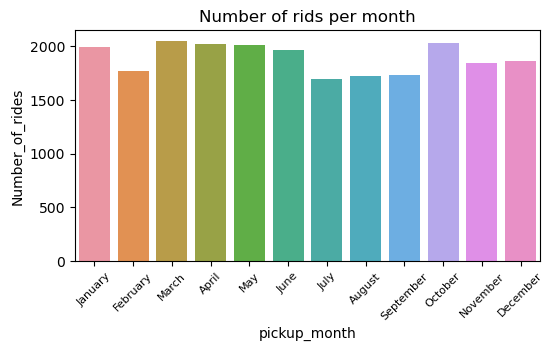

In [26]:
plt.figure(figsize=(6,3))
ax = sns.barplot(x=pickup_counts['pickup_month'], y=pickup_counts['Number_of_rides'])

plt.xticks(rotation=45, fontsize=8)
plt.title ('Number of rids per month')
plt.show()

Number of rides varies from minimum of 1724 in August to maximum of 2049 in March.
Ovearl trend is consistent with drops in the summer months of July, August and September as well as February.

**Count of rides throughout the year 2017 by week days**

In [27]:
df['pickup_day'].value_counts()
pickup_counts_day = df[['pickup_day', 'passenger_count']].groupby('pickup_day').count().reset_index()

# Reorder the 'pickup_day' column based on the custom order list od "order" below
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pickup_counts_day['pickup_day'] = pd.Categorical(pickup_counts_day['pickup_day'], categories=order, ordered=True)

# Nowe, let's sort the DataFrame based on the 'pickup_day' column (now ordered)
pickup_counts_day = pickup_counts_day.sort_values('pickup_day')
pickup_counts_day

# rename the 'passenger_count' column in this dataframe
pickup_counts_day = pickup_counts_day.rename(columns={'passenger_count': 'Number_of_rides'})
pickup_counts_day 

,pickup_day,Number_of_rides
1,Monday,2931
5,Tuesday,3198
6,Wednesday,3390
4,Thursday,3402
0,Friday,3413
2,Saturday,3367
3,Sunday,2998


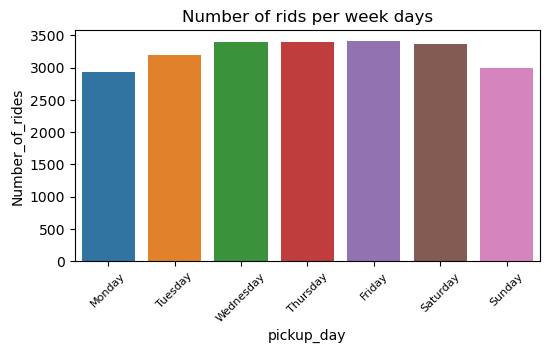

In [28]:
plt.figure(figsize=(6,3))
ax = sns.barplot(x=pickup_counts_day['pickup_day'], y=pickup_counts_day['Number_of_rides'])

plt.xticks(rotation=45, fontsize=8)
plt.title ('Number of rids per week days')
plt.show()

 The least number of rides are observed for the trips made on Monday, Sunday and Tuesday while the lorager count of ride happen on Wednesday, Thursday, Friday and Saturday.

**Sume total_amount by pick up month**

In [29]:
month_total_amount = df[['pickup_month', 'total_amount']].groupby('pickup_month').sum().reset_index()

# Reorder the 'pickup_month' column based on the custom order list od "order" below
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
         'August', 'September', 'October', 'November', 'December']
month_total_amount['pickup_month'] = pd.Categorical(month_total_amount['pickup_month'], categories=order, ordered=True)


month_total_amount = month_total_amount.sort_values('pickup_month')
month_total_amount

month_total_amount = month_total_amount.rename(columns={'total_amount': 'sum_total'})
month_total_amount

,pickup_month,sum_total
4,January,31735.25
3,February,28937.89
7,March,33085.89
0,April,32012.54
8,May,33828.58
6,June,32920.52
5,July,26617.64
1,August,27759.56
11,September,28206.38
10,October,33065.83


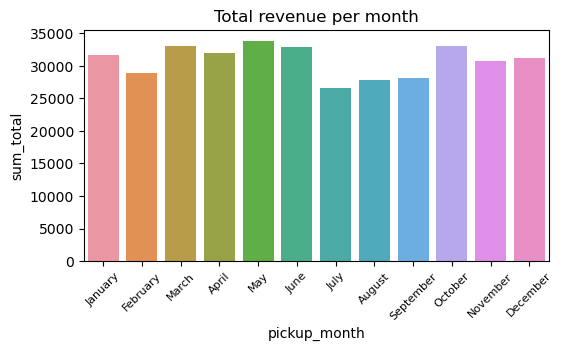

In [30]:
plt.figure(figsize=(6,3))
ax = sns.barplot(x=month_total_amount['pickup_month'], y=month_total_amount['sum_total'])

plt.xticks(rotation=45, fontsize=8)
plt.title ('Total revenue per month')
plt.show()

As expected, the total revenue follows the same pattern as number of ride per month as it is the least for summer months of July, August , September as well as  Febuary. 

**Sume total_amount by pick up day**

In [31]:
day_total_amount = df[['pickup_day', 'total_amount']].groupby('pickup_day').sum().reset_index()


# Reorder the 'pickup_month' column based on the custom order list od "order" below
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_total_amount['pickup_day'] = pd.Categorical(day_total_amount['pickup_day'], categories=order, ordered=True)


day_total_amount = day_total_amount.sort_values('pickup_day')
day_total_amount

day_total_amount = day_total_amount.rename(columns={'total_amount': 'sum_total'})
day_total_amount

,pickup_day,sum_total
1,Monday,49574.37
5,Tuesday,52527.14
6,Wednesday,55310.47
4,Thursday,57181.91
0,Friday,55818.74
2,Saturday,51195.40
3,Sunday,48624.06


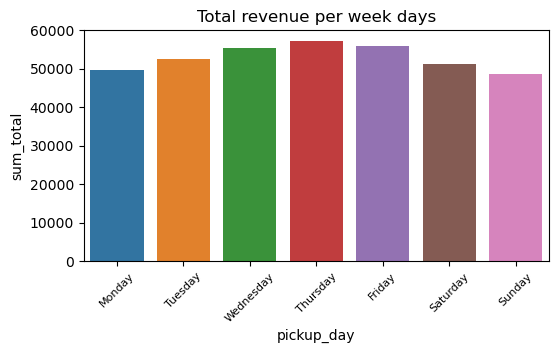

In [32]:
plt.figure(figsize=(6,3))
ax = sns.barplot(x=day_total_amount['pickup_day'], y=day_total_amount['sum_total'])

plt.xticks(rotation=45, fontsize=8)
plt.title ('Total revenue per week days')
plt.show()

Thursday trips result in largest amount to revenuw, while Monday and Sunday have least revenue. 
 As expected form the number of rides pwr weekday, Wednesday, Thursday and Friday have higher total revenue.
 Interestingly, even though Satuday has only 35 rides less that Thursday, but the revenue drops from 57181 to 51195 $ from Thursday to Saturday.  There is about 10% decrease in revenue from Thursday to Saturday rides with only 35 drops of ride counts. 
 
 Similarly, Monday we have 2931 rides which is 471 rides less than the Thursday rides. Hoever, the drop in the revenue for Monday is the same as Saturday. 10% drop of revenue is observed for both Monday and Saturday, but the number of rides are 2931 and 3367 respectively for Monday and Saturday. 

**Plot mean trip distance by drop-off location**

In [34]:
df['PULocationID'].nunique(), df['DOLocationID'].nunique()

(152, 216)

In [62]:
trip_dist_DOLoc = df[['DOLocationID', 'trip_distance']].groupby('DOLocationID').mean('trip_distance').reset_index()

trip_dist_DOLoc = trip_dist_DOLoc.sort_values(by='trip_distance')
trip_dist_DOLoc

,DOLocationID,trip_distance
164,207,1.200000
154,193,1.390556
192,237,1.555494
189,234,1.727806
109,137,1.818852
...,...,...
40,51,17.310000
5,11,17.945000
167,210,20.500000
21,29,21.650000


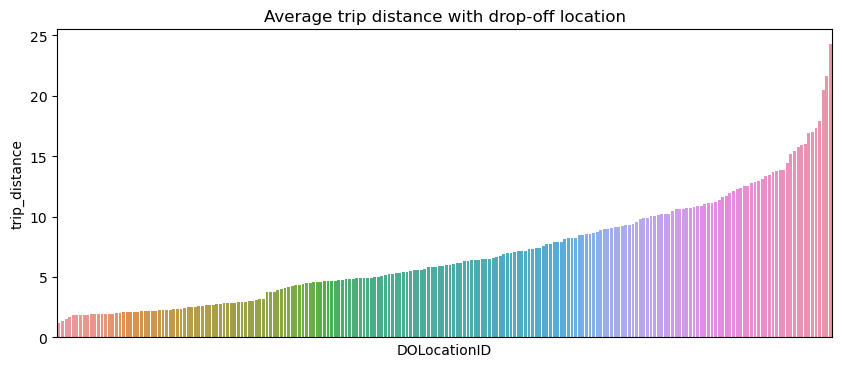

In [64]:
plt.figure(figsize=(10,4))
ax = sns.barplot(x=trip_dist_DOLoc['DOLocationID'], 
                 y=trip_dist_DOLoc['trip_distance'], 
                order=trip_dist_DOLoc['DOLocationID'])
ax.set_xticks([])
ax.set_xticklabels([])
plt.title('Average trip distance with drop-off location');
plt.show()

This plot shows that the drop-off points are relatively evenly distributed over the terrain. This is good to know, because geographic coordinates were not included in this dataset, so there was no obvious way to test for the distibution of locations. 


- To confirm this conclusion, consider the following experiment:

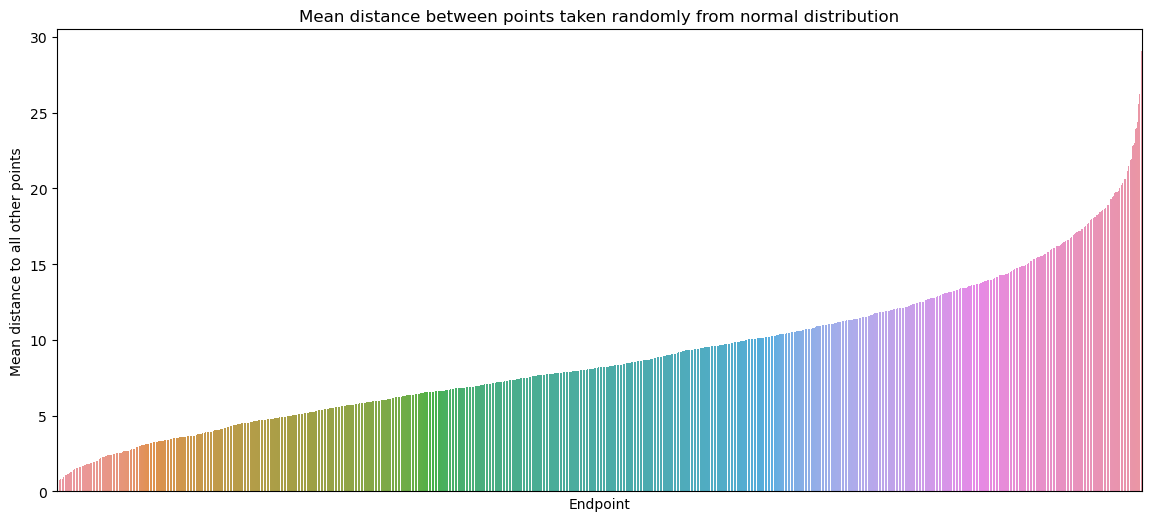

In [65]:
# 1. Generate random points on a 2D plane from a normal distribution
test = np.round(np.random.normal(10, 5, (3000, 2)), 1)
midway = int(len(test)/2)  # Calculate midpoint of the array of coordinates
start = test[:midway]      # Isolate first half of array ("pick-up locations")
end = test[midway:]        # Isolate second half of array ("drop-off locations")

# 2. Calculate Euclidean distances between points in first half and second half of array
distances = (start - end)**2           
distances = distances.sum(axis=-1)
distances = np.sqrt(distances)

# 3. Group the coordinates by "drop-off location", compute mean distance
test_df = pd.DataFrame({'start': [tuple(x) for x in start.tolist()],
                   'end': [tuple(x) for x in end.tolist()],
                   'distance': distances})
data = test_df[['end', 'distance']].groupby('end').mean()
data = data.sort_values(by='distance')

# 4. Plot the mean distance between each endpoint ("drop-off location") and all points it connected to
plt.figure(figsize=(14,6))
ax = sns.barplot(x=data.index,
                 y=data['distance'],
                 order=data.index)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_xlabel('Endpoint')
ax.set_ylabel('Mean distance to all other points')
ax.set_title('Mean distance between points taken randomly from normal distribution');

Comparing the above two barplots reveals that the drop off locations are evely distributed geographically. However, this doesn't mean thet there is an even distribution of rides to each drop off point. We will examin this next.

**Ride distribution over drop off location IDs**

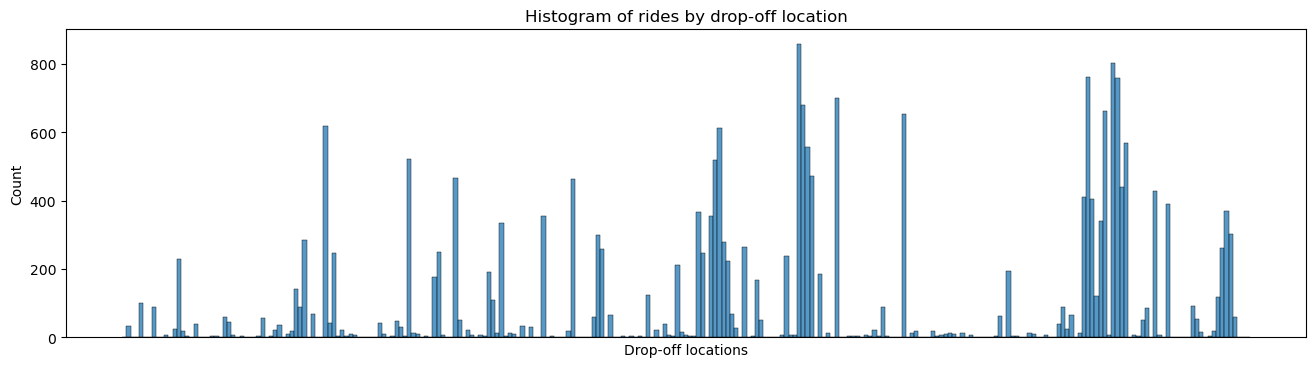

In [88]:
plt.figure(figsize=(16,4))
sns.histplot(df['DOLocationID'], bins=range(0, 270, 1))
plt.xticks([])
plt.xlabel('Drop-off locations')
plt.title('Histogram of rides by drop-off location');

As it is observed, out of ~270 locations, the distribustion of rides is disproportionate maning that un-even distribution of rides according to different locations is obsevred. Some locations have great number of rides whil some have zero or very low numbr of rides. 

**trip-duration Calculations**

In [89]:
df['trip_duration'] = df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']

In [90]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,time_diff,min_diff,pickup_month,drop_month,pickup_day,drop_day,trip_duration
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.3,16.56,0 days 00:14:04,14.066667,March,March,Saturday,Saturday,0 days 00:14:04
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.3,20.80,0 days 00:26:30,26.500000,April,April,Tuesday,Tuesday,0 days 00:26:30
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.3,8.75,0 days 00:07:12,7.200000,December,December,Friday,Friday,0 days 00:07:12
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.3,27.69,0 days 00:30:15,30.250000,May,May,Sunday,Sunday,0 days 00:30:15
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.0,0.3,17.80,0 days 00:16:43,16.716667,April,April,Saturday,Saturday,0 days 00:16:43


- EDA helps a data professional to get to know the data, understand its outliers, clean its missing values, and prepare it for future modeling.
- That this dataset has some outliers that we will need to make decisions on prior to designing a model.

# KEY INSIGHTS 

After running initial exploratory data analysis (EDA) on a sample of the data provided by New York City TLC, it is clear that some of the data will prove an obstacle for accurate ride fare prediction. Namely, trips that have a total cost entered, but a total distance of “0.” At this point, our analysis indicates these to be anomalies or outliers that need to be factored into the algorithm or removed completely.

## Proposed solution: 
After analysis, we recommend removing outliers with a total distanced recorded of 0. 


## Keys to success
Ensuring with New York City TLC that the sample provided is an accurate reflection of their data as a whole.
Plan for handling other outliers, such as low trip distance paired with high costs.
